In [1]:
import numpy as np
import matplotlib.pyplot as plt

# data
from CleanDataPreliminary import *
from PredictionS2_tensorflow import *

Best val MSE: 15.134716987609863
Best params: {'max_depth': 3, 'learning_rate': 0.3, 'n_estimators': 300}
Best iteration (early stop): 279
TensorBoard logdir: runs/xgb_20260209-143607


In [2]:
print(model.best_iteration, model.best_score)


42 3.8699458978141266


In [3]:
from CI_banwidth_simple import *

Saved to: runs/xgb_20260209-143708
        date    n  predicted       lower       upper
0 2020-02-15   39       27.0   18.055728   35.944272
1 2020-02-16   32       28.0   17.416995   38.583005
2 2020-02-17  145      123.0  107.508067  138.491933
3 2020-02-18  125      110.0   94.508067  125.491933
4 2020-02-19  132      100.0   86.143594  113.856406


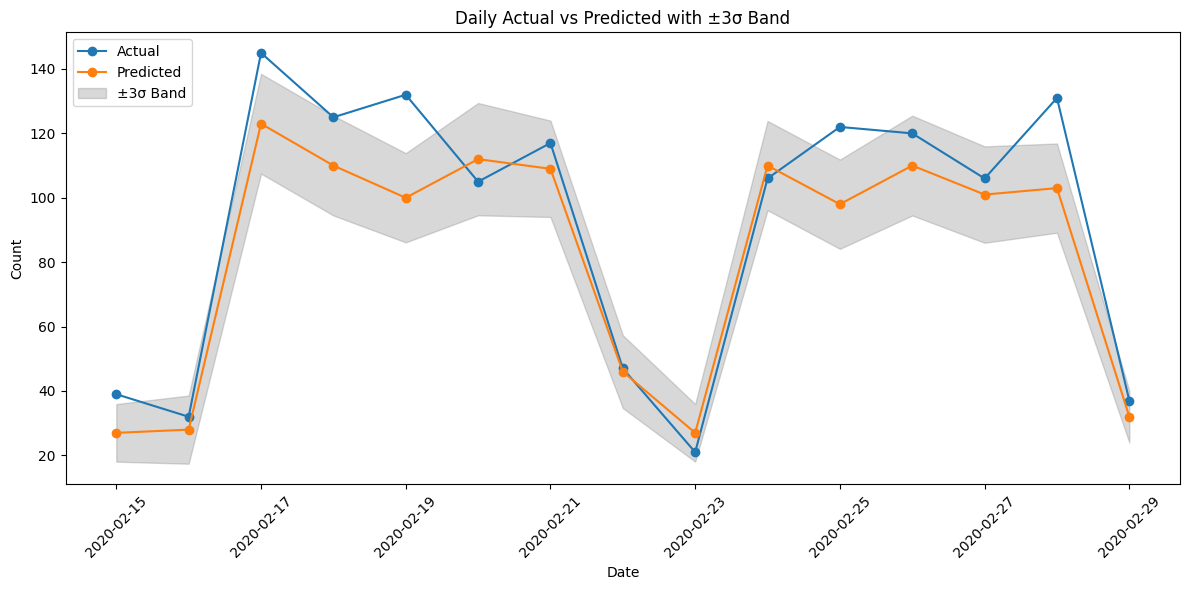

In [4]:
from CI_banwidth_simple import *
# plot
plt.figure(figsize=(12, 6))
plt.plot(daily["date"], daily["n"], label="Actual", marker="o")
plt.plot(daily["date"], daily["predicted"], label="Predicted", marker="o")
plt.fill_between(daily["date"], daily["lower"], daily["upper"], color="gray", alpha=0.3, label="±3σ Band")
plt.xlabel("Date")
plt.ylabel("Count")
plt.title("Daily Actual vs Predicted with ±3σ Band")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
# coverage
coverage = np.mean((daily["n"] >= daily["lower"]) & (daily["n"] <= daily["upper"]))
print(f"Coverage of ±3σ Band: {coverage:.2%}")
# width
daily["bandwidth"] = daily["upper"] - daily["lower"]
average_bandwidth = daily["bandwidth"].mean()
print(f"Average Bandwidth: {average_bandwidth:.2f}")

Coverage of ±3σ Band: 66.67%
Average Bandwidth: 26.27


In [6]:
res = S2_test_results["residual_raw"].values.astype(float)
rng = np.random.default_rng(0)

def band_for_m(m, alpha=0.10, B=20000):
    sims = rng.choice(res, size=(B, m), replace=True).sum(axis=1)
    lo, hi = np.quantile(sims, [alpha/2, 1-alpha/2])
    return lo, hi

daily["lo_err"], daily["hi_err"] = zip(*[band_for_m(int(m)) for m in daily["m"]])
daily["lower"] = daily["predicted"] + daily["lo_err"]
daily["upper"] = daily["predicted"] + daily["hi_err"]


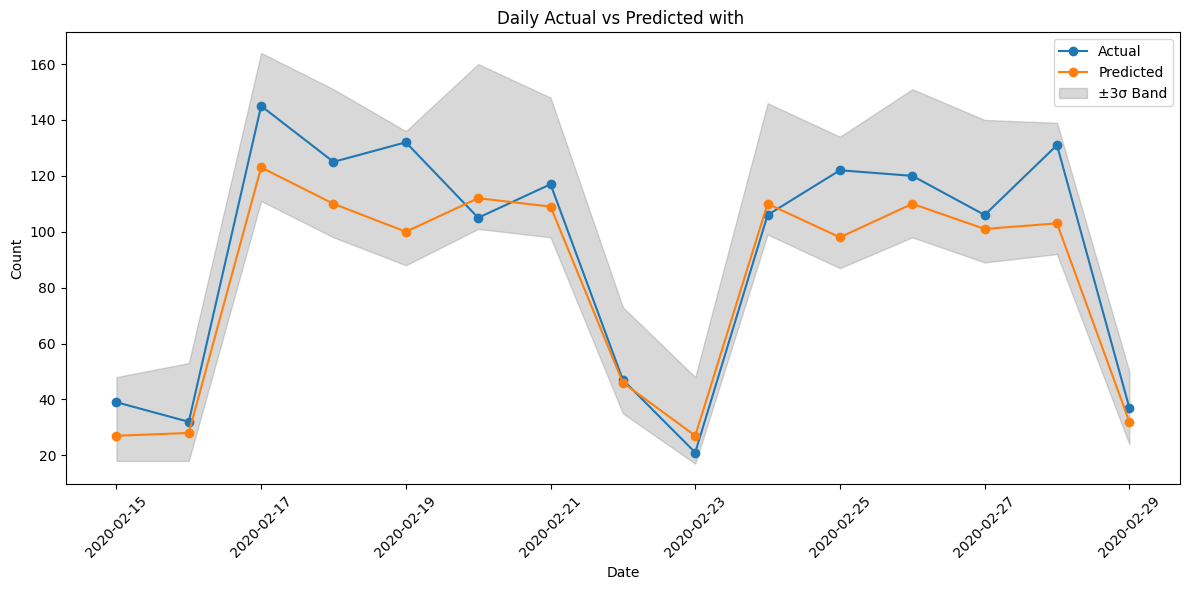

In [7]:
# plot
plt.figure(figsize=(12, 6))
plt.plot(daily["date"], daily["n"], label="Actual", marker="o")
plt.plot(daily["date"], daily["predicted"], label="Predicted", marker="o")
plt.fill_between(daily["date"], daily["lower"], daily["upper"], color="gray", alpha=0.3, label="±3σ Band")
plt.xlabel("Date")
plt.ylabel("Count")
plt.title("Daily Actual vs Predicted with ")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
# coverage
coverage = np.mean((daily["n"] >= daily["lower"]) & (daily["n"] <= daily["upper"]))
print(f"Coverage of ±3σ Band: {coverage:.2%}")
# width
daily["bandwidth"] = daily["upper"] - daily["lower"]
average_bandwidth = daily["bandwidth"].mean()
print(f"Average Bandwidth: {average_bandwidth:.2f}")

Coverage of ±3σ Band: 100.00%
Average Bandwidth: 44.54


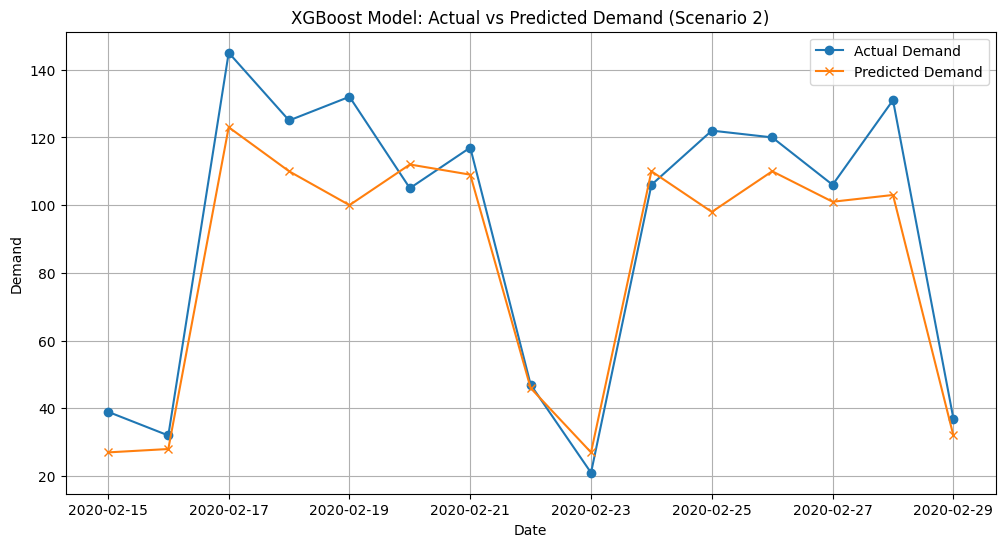

In [9]:
# plot
plt.figure(figsize=(12, 6))
plt.plot(S2_daily_agg['date'], S2_daily_agg['n'], label='Actual Demand', marker='o')
plt.plot(S2_daily_agg['date'], S2_daily_agg['predicted'], label='Predicted Demand', marker='x')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.title('XGBoost Model: Actual vs Predicted Demand (Scenario 2)')
plt.legend()
plt.grid()
plt.show()

# CI's

## Residual-based (Normal)
For this, we have to assume a distribution

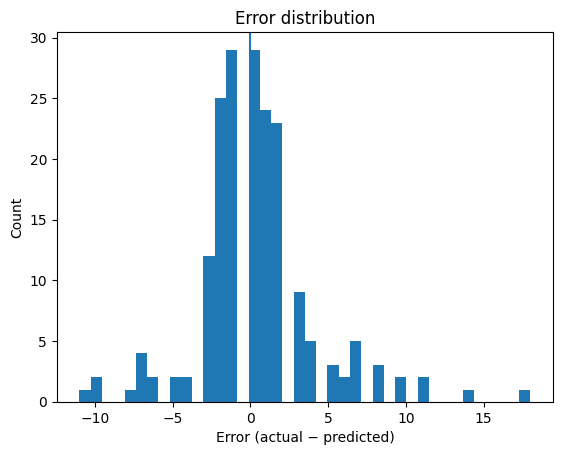

In [10]:
errors = y_val - val_pred

plt.hist(errors, bins=40)
plt.axvline(0)
plt.xlabel("Error (actual − predicted)")
plt.ylabel("Count")
plt.title("Error distribution")
plt.show()


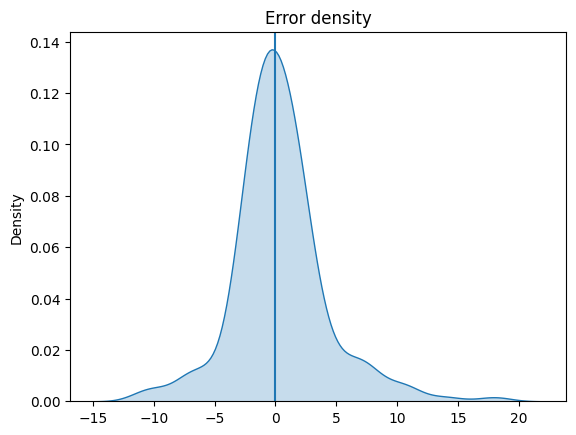

In [11]:
import seaborn as sns
errors = y_val - val_pred
sns.kdeplot(errors, fill=True)
plt.axvline(0)
plt.title("Error density")
plt.show()


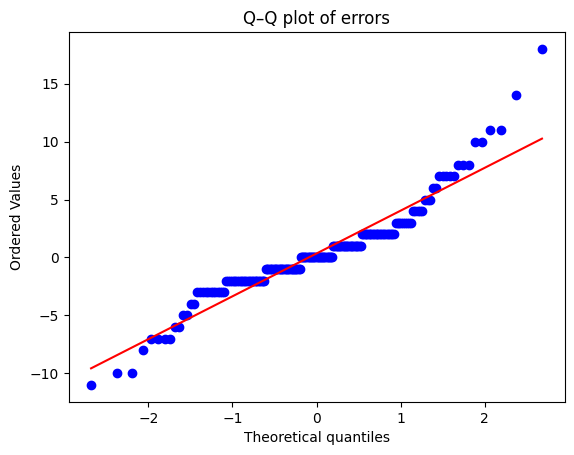

In [12]:
import scipy.stats as stats

stats.probplot(errors, dist="norm", plot=plt)
plt.title("Q–Q plot of errors")
plt.show()


# Residual-based (Empirical) (baseline)

In [13]:
q_low, q_high = np.quantile(errors, [0.05, 0.95])
print(f"5th percentile: {q_low:.2f}, 95th percentile: {q_high:.2f}")


5th percentile: -5.60, 95th percentile: 7.00


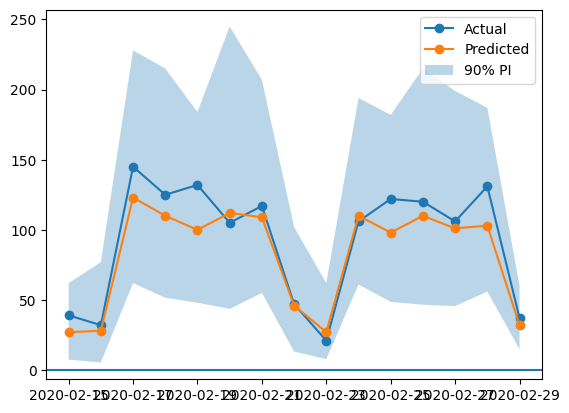

In [14]:
test_lower = np.maximum(test_pred + q_low, 0)  # Ensure lower bound is 0
test_upper = test_pred + q_high

S2_test_results = test_data_S2.copy()
S2_test_results['predicted'] = test_pred
S2_test_results['lower_90'] = test_lower
S2_test_results['upper_90'] = test_upper

S2_daily_agg = S2_test_results.groupby('date').agg(
    n=('n', 'sum'),
    predicted=('predicted', 'sum'),
    lower_90=('lower_90', 'sum'),
    upper_90=('upper_90', 'sum')
).reset_index()

plt.plot(S2_daily_agg['date'], S2_daily_agg['n'], marker='o', label='Actual')
plt.plot(S2_daily_agg['date'], S2_daily_agg['predicted'], marker='o', label='Predicted')
plt.fill_between(S2_daily_agg['date'], S2_daily_agg['lower_90'], S2_daily_agg['upper_90'], alpha=0.3, label='90% PI')
plt.axhline(0)
plt.legend()
plt.show()



In [15]:
coverage = np.mean((y_test >= test_lower) & (y_test <= test_upper))
print("Test coverage:", coverage)


Test coverage: 0.8994082840236687


## Quantile Regression (XGBoost quantile loss)
for this, we have to retrain the model as we now use quantileerror instead of sqerror

In [16]:
def train_quantile_model(alpha):
    params = {
        "objective": "reg:quantileerror",
        "quantile_alpha": alpha,
        "max_depth": 6,
        "learning_rate": 0.03,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "seed": 43,
    }

    model_qt = xgb.train(
        params=params,
        dtrain=dtrain,
        num_boost_round=1200,
        evals=[(dval, "val")],
        early_stopping_rounds=50,
        verbose_eval=False,
    )
    return model_qt


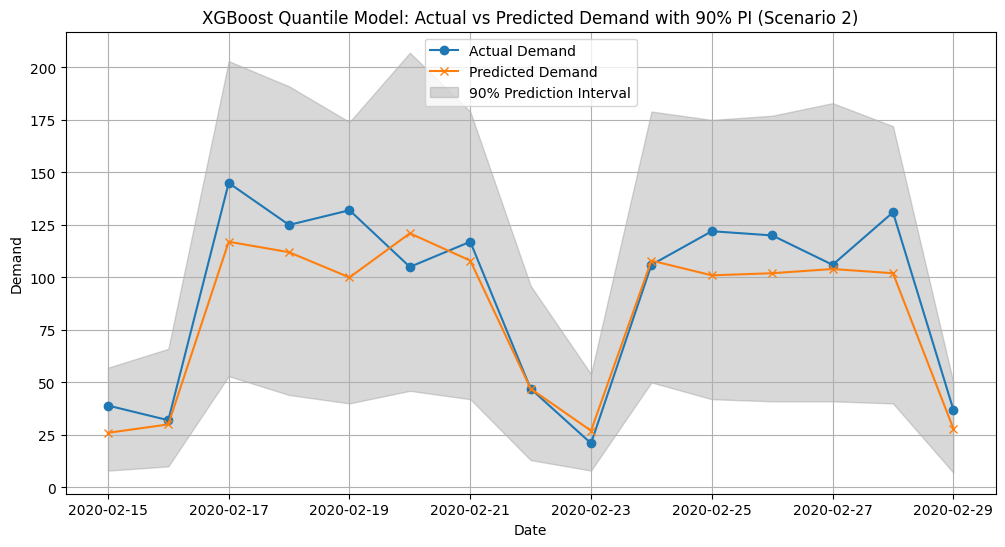

In [17]:
model_q05 = train_quantile_model(0.05)
model_q50 = train_quantile_model(0.50)
model_q95 = train_quantile_model(0.95)

q05_pred = np.round(model_q05.predict(dtest))
q50_pred = np.round(model_q50.predict(dtest))
q95_pred = np.round(model_q95.predict(dtest))

S2_test_results = test_data_S2.copy()
S2_test_results["predicted"] = q50_pred
S2_test_results["lower_90"] = q05_pred
S2_test_results["upper_90"] = q95_pred

S2_daily_agg = S2_test_results.groupby("date").agg(
    n=("n", "sum"),
    predicted=("predicted", "sum"),
    lower_90=("lower_90", "sum"),
    upper_90=("upper_90", "sum"),
).reset_index()

# plot
plt.figure(figsize=(12, 6))
plt.plot(S2_daily_agg["date"], S2_daily_agg["n"], label="Actual Demand", marker="o")
plt.plot(S2_daily_agg["date"], S2_daily_agg["predicted"], label="Predicted Demand", marker="x")
plt.fill_between(
    S2_daily_agg["date"],
    S2_daily_agg["lower_90"],
    S2_daily_agg["upper_90"],
    color="gray",
    alpha=0.3,
    label="90% Prediction Interval",
)
plt.xlabel("Date")
plt.ylabel("Demand")
plt.title("XGBoost Quantile Model: Actual vs Predicted Demand with 90% PI (Scenario 2)")
plt.legend()
plt.grid()
plt.show()

In [18]:
coverage = np.mean(
    (y_test >= q05_pred) & (y_test <= q95_pred)
)
print("90% interval coverage:", coverage)


90% interval coverage: 0.9289940828402367


In [19]:
emp_width = np.mean(q_high - q_low)
qgb_width = np.mean(q95_pred - q05_pred)

print("Empirical avg width:", emp_width)
print("Quantile XGB avg width:", qgb_width)


Empirical avg width: 12.6
Quantile XGB avg width: 9.928994


## Bootstrap

In [20]:
train_pred = model.predict(dtrain)
train_residuals = y_train - train_pred
res_df = train_data_S2[['date']].copy()
res_df['residual'] = train_residuals


In [21]:
def make_residual_blocks(df, block_size):
    blocks = []
    dates = df['date'].sort_values().unique()
    for i in range(len(dates) - block_size + 1):
        block_dates = dates[i:i+block_size]
        blocks.append(df[df['date'].isin(block_dates)]['residual'].values)
    return blocks

BLOCK_SIZE = 7  # try 7–14
res_blocks = make_residual_blocks(res_df, BLOCK_SIZE)


In [22]:
N_BOOT = 500
rng = np.random.default_rng(43)

point_pred = model.predict(dtest)
boot_preds = []

B = len(res_blocks)

for _ in range(N_BOOT):
    idx = rng.integers(0, B, size=B)
    sampled_residuals = np.concatenate([res_blocks[i] for i in idx])

    sampled_residuals = sampled_residuals[:len(point_pred)]
    boot_preds.append(point_pred + sampled_residuals)

boot_preds = np.array(boot_preds)


In [23]:
lower_90 = np.percentile(boot_preds, 5, axis=0)
upper_90 = np.percentile(boot_preds, 95, axis=0)
median   = np.percentile(boot_preds, 50, axis=0)


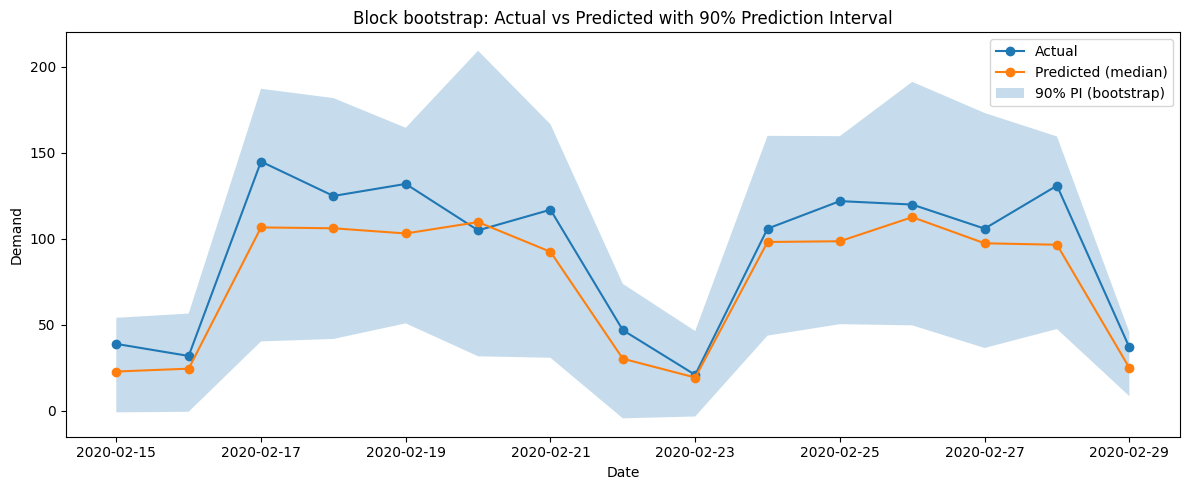

In [24]:
# ----- attach to test rows -----
S2_test_results = test_data_S2.copy()
S2_test_results["predicted"] = median
S2_test_results["lower_90"] = lower_90
S2_test_results["upper_90"] = upper_90

# ----- aggregate by date (sum actual + bounds) -----
S2_daily_agg_boot = S2_test_results.groupby("date").agg(
    n=("n", "sum"),
    predicted=("predicted", "sum"),
    lower_90=("lower_90", "sum"),
    upper_90=("upper_90", "sum"),
).reset_index()

# ----- plot -----
plt.figure(figsize=(12, 5))
plt.plot(S2_daily_agg_boot["date"], S2_daily_agg_boot["n"], marker="o", label="Actual")
plt.plot(S2_daily_agg_boot["date"], S2_daily_agg_boot["predicted"], marker="o", label="Predicted (median)")
plt.fill_between(
    S2_daily_agg_boot["date"],
    S2_daily_agg_boot["lower_90"],
    S2_daily_agg_boot["upper_90"],
    alpha=0.25,
    label="90% PI (bootstrap)"
)
plt.xlabel("Date")
plt.ylabel("Demand")
plt.title("Block bootstrap: Actual vs Predicted with 90% Prediction Interval")
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
coverage = np.mean((y_test >= lower_90) & (y_test <= upper_90))
avg_width = np.mean(upper_90 - lower_90)

print("Bootstrap 90% coverage:", coverage)
print("Bootstrap avg width:", avg_width)


Bootstrap 90% coverage: 0.8757396449704142
Bootstrap avg width: 10.91531185786399


## Split conformal (asymmetric)

In [33]:
alpha = 0.10
val_pred = model.predict(dval)
err = y_val - val_pred

n = len(err)
q_lo = np.quantile(-err, np.ceil((n + 1) * (1 - alpha/2)) / n, method="higher")  # for lower bound
q_hi = np.quantile( err, np.ceil((n + 1) * (1 - alpha/2)) / n, method="higher")  # for upper bound

print("q_lo, q_hi:", q_lo, q_hi)


q_lo, q_hi: 6.040994644165039 8.434722900390625


In [34]:
test_pred = model.predict(dtest)
lower_90 = test_pred - q_lo
upper_90 = test_pred + q_hi


In [39]:
S2_test_results = test_data_S2.copy()
S2_test_results["predicted"] = np.round(test_pred)
S2_test_results["lower_90"] = lower_90
S2_test_results["upper_90"] = upper_90

S2_daily_agg_conf = S2_test_results.groupby("date").agg(
    n=("n", "sum"),
    predicted=("predicted", "sum"),
    lower_90=("lower_90", "sum"),
    upper_90=("upper_90", "sum"),
).reset_index()


In [40]:
coverage = np.mean((y_test >= lower_90) & (y_test <= upper_90))
avg_width = np.mean(upper_90 - lower_90)
print("Asymmetric conformal 90% coverage:", coverage)
print("Avg width:", avg_width)

Asymmetric conformal 90% coverage: 0.9112426035502958
Avg width: 14.475717544555664


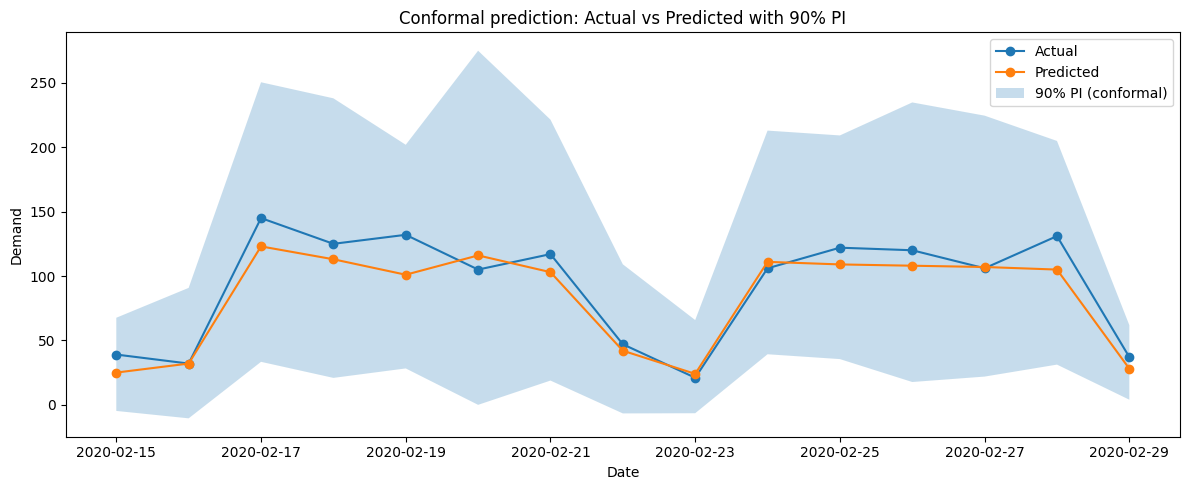

In [41]:
plt.figure(figsize=(12,5))
plt.plot(S2_daily_agg_conf["date"], S2_daily_agg_conf["n"], marker="o", label="Actual")
plt.plot(S2_daily_agg_conf["date"], S2_daily_agg_conf["predicted"], marker="o", label="Predicted")
plt.fill_between(S2_daily_agg_conf["date"], S2_daily_agg_conf["lower_90"], S2_daily_agg_conf["upper_90"],
                 alpha=0.25, label="90% PI (conformal)")
plt.title("Conformal prediction: Actual vs Predicted with 90% PI")
plt.xlabel("Date"); plt.ylabel("Demand")
plt.legend(); plt.tight_layout(); plt.show()


## conformal calibration on top of quantile XGB

In [ ]:
model_q05 = train_quantile_model(0.05)
model_q50 = train_quantile_model(0.50)
model_q95 = train_quantile_model(0.95)

q05_pred = np.round(model_q05.predict(dtest))
q50_pred = np.round(model_q50.predict(dtest))
q95_pred = np.round(model_q95.predict(dtest))


In [58]:
alpha = 0.10  # 90% PI

# Predict quantiles on validation
q05_val = model_q05.predict(dval)
q95_val = model_q95.predict(dval)

# Predict quantiles on test
q05_test = model_q05.predict(dtest)
q95_test = model_q95.predict(dtest)


In [59]:
scores = np.maximum(q05_val - y_val, y_val - q95_val)
scores = np.maximum(scores, 0.0)  # optional safety


In [60]:
n = len(scores)
qhat = np.quantile(scores, np.ceil((n + 1) * (1 - alpha)) / n, method="higher")
print("CQR inflation qhat:", qhat)


CQR inflation qhat: 0.10037243366241455


In [68]:
lower_90 = q05_test - qhat
upper_90 = q95_test + qhat
pred_med = model_q50.predict(dtest)


In [69]:
coverage = np.mean((y_test >= lower_90) & (y_test <= upper_90))
avg_width = np.mean(upper_90 - lower_90)

print("CQR 90% coverage:", coverage)
print("CQR avg width:", avg_width)


CQR 90% coverage: 0.893491124260355
CQR avg width: 10.09415914744315


In [70]:
S2_test_results = test_data_S2.copy()
S2_test_results["predicted"] = pred_med
S2_test_results["lower_90"] = lower_90
S2_test_results["upper_90"] = upper_90

S2_daily_agg_cqr = S2_test_results.groupby("date").agg(
    n=("n", "sum"),
    predicted=("predicted", "sum"),
    lower_90=("lower_90", "sum"),
    upper_90=("upper_90", "sum"),
).reset_index()


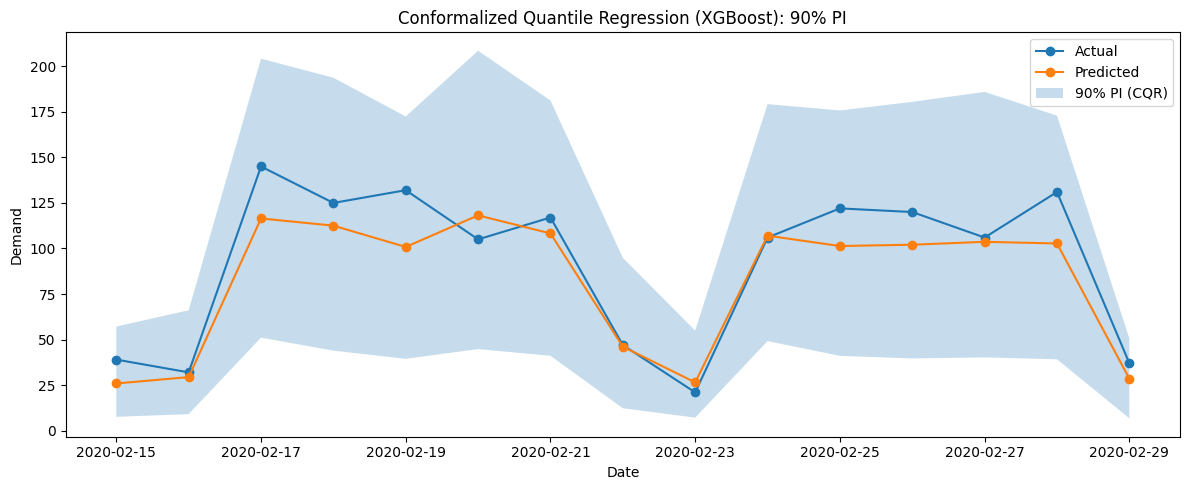

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(S2_daily_agg_cqr["date"], S2_daily_agg_cqr["n"], marker="o", label="Actual")
plt.plot(S2_daily_agg_cqr["date"], S2_daily_agg_cqr["predicted"], marker="o", label="Predicted")
plt.fill_between(S2_daily_agg_cqr["date"], S2_daily_agg_cqr["lower_90"], S2_daily_agg_cqr["upper_90"],
                 alpha=0.25, label="90% PI (CQR)")
plt.title("Conformalized Quantile Regression (XGBoost): 90% PI")
plt.xlabel("Date"); plt.ylabel("Demand")
plt.legend(); plt.tight_layout(); plt.show()


| Method                             | Coverage  | Avg width    | Verdict                |
| ---------------------------------- | --------- | ------------ | ---------------------- |
| Empirical residual                 | ~0.90     | Medium       | Baseline               |
| Quantile XGB                       | ~0.93     | **Smallest** | Sharp but uncalibrated |
| Asym. conformal (mean XGB)         | **0.91**  | ~14.5        | Safe but wider         |
| **CQR (quantile XGB + conformal)** | **0.89**  | **~10.1**    | **Best trade-off**     |
| Bootstrap                          | 0.88 | Large        | Invalid here           |


In [11]:
import numpy as np
import matplotlib.pyplot as plt

def residuals_in_ci(y, yhat, lo, hi):
    y   = np.asarray(y).astype(float)
    yhat= np.asarray(yhat).astype(float)
    lo  = np.asarray(lo).astype(float)
    hi  = np.asarray(hi).astype(float)

    r = y - yhat
    inside = (y >= lo) & (y <= hi)

    r_in  = r[inside]
    r_out = r[~inside]

    print("Coverage:", inside.mean())
    print("Inside CI residuals:  mean=", r_in.mean(), " std=", r_in.std(), " n=", len(r_in))
    print("Outside CI residuals: mean=", r_out.mean(), " std=", r_out.std(), " n=", len(r_out))

    plt.figure()
    plt.hist(r_in, bins=40, alpha=0.7, label="residuals (inside CI)")
    plt.hist(r_out, bins=40, alpha=0.7, label="residuals (outside CI)")
    plt.xlabel("residual = y - yhat")
    plt.ylabel("count")
    plt.legend()
    plt.show()

    return r_in, r_out, inside
r_in, r_out, inside = residuals_in_ci(y_test, pred_med, lower_90, upper_90)

ValueError: operands could not be broadcast together with shapes (169,) (15,) 